# 🎨 Text-Guided AI Image Editor — Minimal Pipeline
**Input:** image + text prompt → **Output:** edited image

Pipeline: `YOLO (mask)` → `CLIP (text)` + `VAE (image)` → `DDPM / U-Net` → `VAE decode`

In [1]:
# ── Install ───────────────────────────────────────────────────────────────────
!pip install diffusers transformers accelerate ultralytics Pillow xformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 96.1 MB/s eta 0:00:00


In [2]:
# ── Imports & device ─────────────────────────────────────────────────────────
import torch
import numpy as np
from PIL import Image, ImageFilter
from diffusers import StableDiffusionInpaintPipeline
from ultralytics import YOLO
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [3]:
# ── Load models (run once) ────────────────────────────────────────────────────
yolo = YOLO("yolov8n.pt")

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-inpainting",
    torch_dtype=torch.float16,
    variant="fp16",
    safety_checker=None,
).to(device)
pipe.enable_attention_slicing()

print("Models ready ✓")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing netw

Models ready ✓


In [4]:
# ── Helper: auto-generate mask with YOLO ─────────────────────────────────────
def make_mask(image: Image.Image, target_class: str = None) -> Image.Image:
    """
    Detect objects with YOLO → return a white/black PIL mask.
    White = region to inpaint | Black = region to keep.
    If target_class is given (e.g. 'car'), only that class is masked.
    Otherwise the highest-confidence detection is used.
    """
    results = yolo(image, verbose=False)[0]
    mask_arr = np.zeros((*image.size[::-1],), dtype=np.uint8)  # H x W, all black

    boxes = results.boxes
    if not len(boxes):
        print("No objects detected — masking full image.")
        return Image.fromarray(np.ones_like(mask_arr) * 255).convert("RGB")

    chosen = None
    for box in boxes:
        name = results.names[int(box.cls[0])]
        if target_class is None or name.lower() == target_class.lower():
            if chosen is None or float(box.conf[0]) > float(chosen.conf[0]):
                chosen = box
                print(f"Masking: '{name}'  conf={float(box.conf[0]):.2f}")

    if chosen is None:
        print(f"'{target_class}' not found — using highest-confidence object instead.")
        chosen = max(boxes, key=lambda b: float(b.conf[0]))

    x1, y1, x2, y2 = map(int, chosen.xyxy[0])
    mask_arr[y1:y2, x1:x2] = 255

    mask = Image.fromarray(mask_arr).convert("RGB")
    return mask.filter(ImageFilter.GaussianBlur(radius=4))  # soften edges

In [5]:
# ── Main function ─────────────────────────────────────────────────────────────
def edit_image(
    image_path: str,
    prompt: str,
    target_class: str = None,       # e.g. 'car', 'person' — None = auto
    negative_prompt: str = "blurry, low quality, distorted",
    steps: int = 30,
    guidance: float = 7.5,
) -> None:
    """
    Full pipeline: load image → YOLO mask → SD inpaint → display result.
    """
    # 1. Load
    original = Image.open(image_path).convert("RGB")

    # 2. YOLO → mask
    mask = make_mask(original, target_class)

    # 3. Resize to 512x512 (SD requirement)
    orig_size = original.size
    img_512  = original.resize((512, 512))
    mask_512 = mask.resize((512, 512))

    # 4. CLIP + VAE + DDPM / U-Net → inpaint
    with torch.autocast(device):
        result_512 = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=img_512,
            mask_image=mask_512,
            num_inference_steps=steps,
            guidance_scale=guidance,
        ).images[0]

    # 5. Resize back & display
    result = result_512.resize(orig_size, Image.LANCZOS)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original);      axes[0].set_title("Original");      axes[0].axis("off")
    axes[1].imshow(mask);          axes[1].set_title("YOLO Mask");      axes[1].axis("off")
    axes[2].imshow(result);        axes[2].set_title(f"Edited");        axes[2].axis("off")
    plt.suptitle(f'Prompt: "{prompt}"', fontsize=12)
    plt.tight_layout()
    plt.show()

    result.save("result.png")
    print("Saved → result.png")

In [6]:
# ── Upload your image then run ────────────────────────────────────────────────

# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load sample image
image_path = "/content/drive/MyDrive/Colab Notebooks/ML2/dog.jpg"

print(f"Uploaded: {image_path}")

Mounted at /content/drive
Uploaded: /content/drive/MyDrive/Colab Notebooks/ML2/dog.jpg


Masking: 'dog'  conf=0.83


  0%|          | 0/30 [00:00<?, ?it/s]

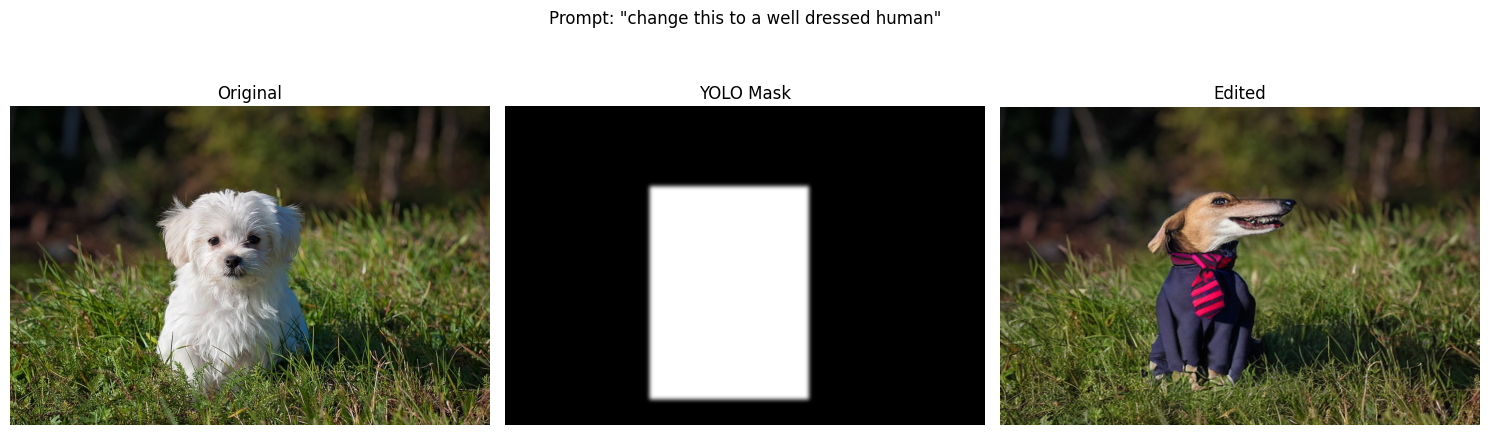

Saved → result.png


In [11]:
# ── ✏️  Edit your image ────────────────────────────────────────────────────────
# Change these two lines — everything else is handled automatically

PROMPT       = "change this to a well dressed human"
TARGET_CLASS = "Dog"      # YOLO class to replace — set to None for auto-detect

edit_image(image_path, PROMPT, target_class=TARGET_CLASS)